# Projeto de Prática em Ciência de Dados

## O Grafo
O primeiro passo foi construir um grafo direcional ponderado, representando o fluxo metabólico, que é feito por um dicionario principal (ciclo_de_krebs). Ele contém os metabólitos do ciclo de krebs, que estão representados por outro dicionário, que contém uma lista com as enzimas necessárias para realizar a etapa do ciclo, sendo essa lista o "preço" que precisa se pagar para chegar em outro metabólito, ou seja, representa que é preciso ter a enzima para realizar a etapa e se tornar outro metabólito

In [83]:
ciclo_de_krebs = {
    "Phosphoenol-pyruvate": {
        "Glycolysis": {}
    },

    "Oxaloacetate": {
        "Phosphoenol-pyruvate": {"enzyme": ["E4.1.1.32"]},
        "Citrate": {"enzyme": ["gltA", "CS"]},
        "(S)-Malate": {"enzyme": ["mdh", "MDH1", "MDH2"]}
    },

    "Citrate": {
        "Oxaloacetate": {"enzyme": ["aclA", "aclB", "CS"]},
        "Isocitrate": {"enzyme": ["acnA", "acnB"]}
    },

    "Isocitrate": {
        "Citrate": {"enzyme": ["acnA", "acnB"]},
        "2-Oxo-glutarate": {"enzyme": ["IDH1", "IDH3", "HICDH"]}
    },

    "2-Oxo-glutarate": {
        "(S)-Succinyl-dihydropoliamide": {"enzyme": ["OGDH","kgd"]},
        "Succinyl-CoA": {"enzyme": ["korA", "korB"]}
    },

    "(S)-Succinyl-dihydropoliamide": {
        "Succinyl-CoA": {"enzyme": ["DLST", "KGB"]}
    },
    
    "Succinyl-CoA": {
        "Succinate": {"enzyme": ["sucC", "sucD"]}
    },

    "Succinate": {
        "Fumarate": {"enzyme": ["sdhA", "sdhB", "sdhC", "sdhD"]}
    },

    "Fumarate": {
        "(S)-Malate": {"enzyme": ["fumA", "fumB", "fumC"]}
    },

    "(S)-Malate": {
        "Oxaloacetate": {"enzyme": ["mdh", "MDH1", "MDH2"]}
    },

    "Pyruvate": {
        "Oxaloacetate": {"enzyme": ["PC", "pycA", "pycB"]},
        "S-Acetyl-dihydrolipoamide": { "enzyme": ["aceE", "PDHA", "PDHB"]}
    },

    "Glycolysis": {
        "Pyruvate": {}
    },

    "Acetyl-CoA": {
        "Oxaloacetate": {"enzyme": ["gltA", "CS"]},
    },

    "S-Acetyl-dihydrolipoamide": {
        "Acetyl-CoA": {"enzyme":["DLAT"]}
    }

}

## Visualização da do Ciclo de Krebs

Nesta etapa, utilizamos as bibliotecas **NetworkX** e **Matplotlib** para construir uma representação gráfica da rede metabólica definida no dicionário acima. O grafo é modelado como uma estrutura direcionada, em que cada nó representa um metabólito e cada aresta representa uma reação bioquímica entre dois compostos.

A disposição dos nós é calculada por meio do algoritmo `spring_layout`, que utiliza um modelo de forças para distribuir os elementos da rede de forma visualmente organizada. Para obter uma representação mais espaçada e facilitar a interpretação, foi utilizada a *seed* 3052, juntamente com os parâmetros ajustados para aumentar a separação entre os nós.

Além da estrutura da rede, as enzimas responsáveis por cada reação são exibidas como rótulos nas arestas, permitindo relacionar diretamente os metabólitos envolvidos com os catalisadores biológicos correspondentes.

Essa visualização fornece uma visão geral do fluxo metabólico do Ciclo de Krebs e de suas interações com vias associadas, como a glicólise e o metabolismo do piruvato, facilitando a análise das rotas bioquímicas representadas no modelo.

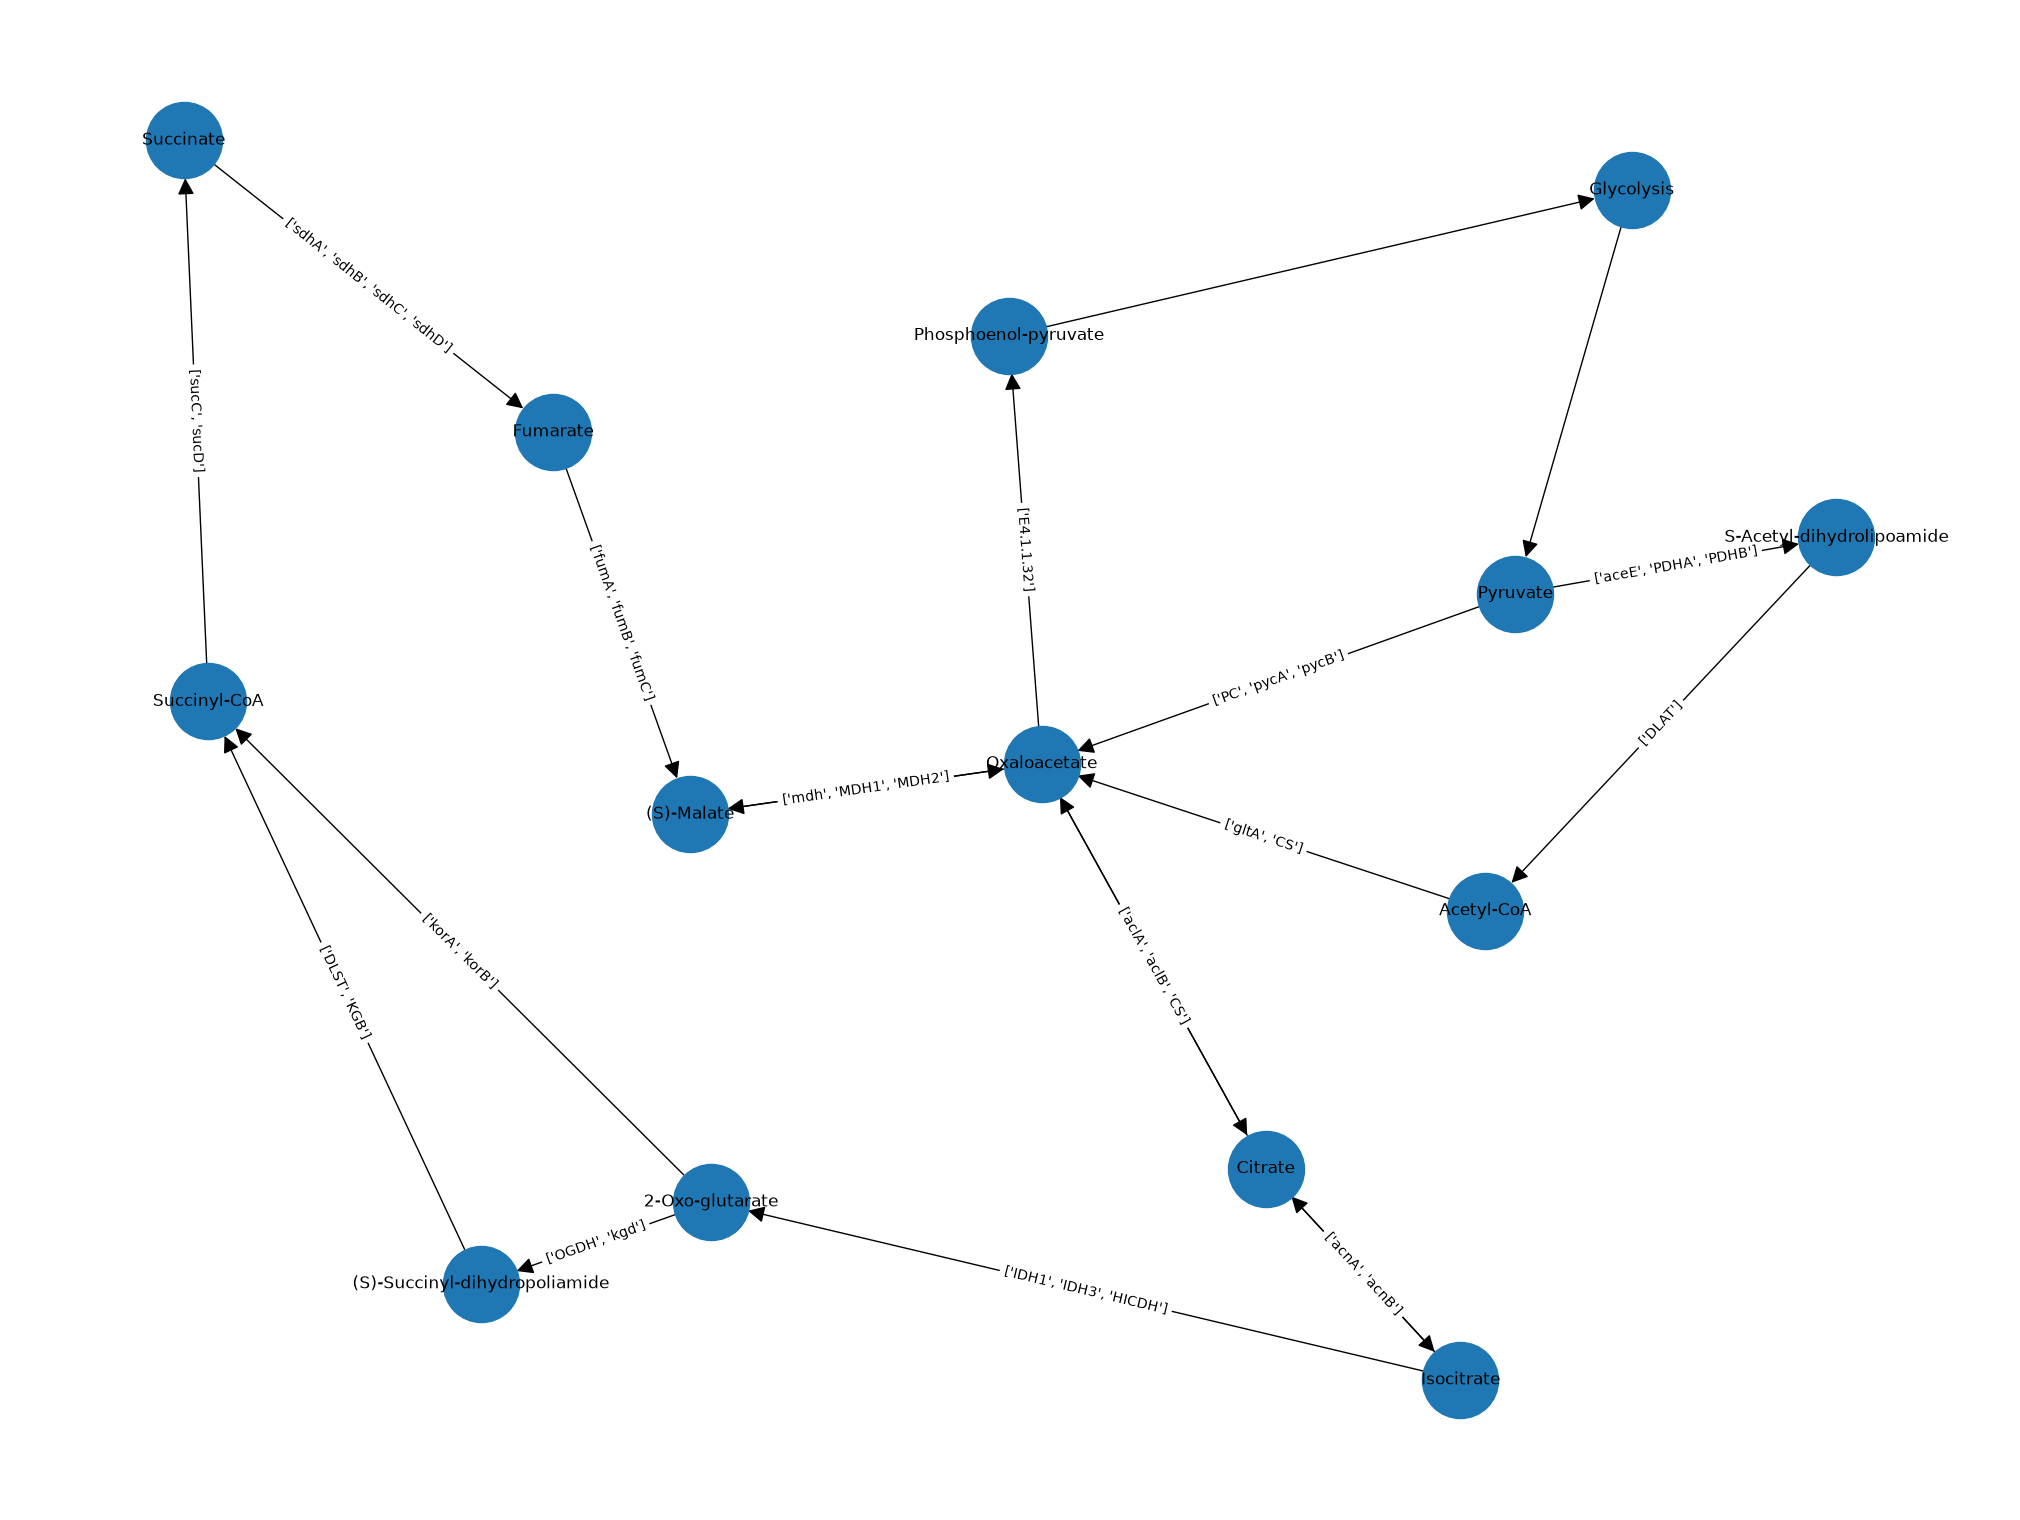

In [84]:
import matplotlib.pyplot as plt
import networkx as nx

g = nx.DiGraph(ciclo_de_krebs)

plt.figure(figsize=(20,15))

posicao = nx.spring_layout(
    g,
    seed=3052,
    k=2,
    iterations=500
)

nx.draw(
    g,
    posicao,
    with_labels=True,
    arrows=True,
    arrowsize=25,
    node_size=3000,
    font_size=12
)

pesos = nx.get_edge_attributes(g, "enzyme")

nx.draw_networkx_edge_labels(
    g,
    posicao,
    edge_labels=pesos,
    font_size=10
)

plt.show()


## Definição das etapas essenciais do Ciclo de Krebs

Nesta etapa, utilizamos a estrutura do dicionário para extrair automaticamente as enzimas associadas às principais reações do Ciclo de Krebs. Cada etapa é representada por um conjunto de enzimas capazes de catalisar a conversão entre dois metabólitos consecutivos.

Essa estrutura servirá como referência para verificar se um determinado organismo possui todas as enzimas necessárias para completar o ciclo metabólico.


In [85]:
etapas_krebs = {
    "Oxaloacetate -> Citrate":
        set(ciclo_de_krebs["Oxaloacetate"]["Citrate"]["enzyme"]),

    "Citrate -> Isocitrate":
        set(ciclo_de_krebs["Citrate"]["Isocitrate"]["enzyme"]),

    "Isocitrate -> 2-Oxo-glutarate":
        set(ciclo_de_krebs["Isocitrate"]["2-Oxo-glutarate"]["enzyme"]),

    "2-Oxo-glutarate -> Succinyl-CoA":
        (
            set(ciclo_de_krebs["2-Oxo-glutarate"]["(S)-Succinyl-dihydropoliamide"]["enzyme"])
            |
            set(ciclo_de_krebs["(S)-Succinyl-dihydropoliamide"]["Succinyl-CoA"]["enzyme"])
            |
            set(ciclo_de_krebs["2-Oxo-glutarate"]["Succinyl-CoA"]["enzyme"])
        ),

    "Succinyl-CoA -> Succinate":
        set(ciclo_de_krebs["Succinyl-CoA"]["Succinate"]["enzyme"]),

    "Succinate -> Fumarate":
        set(ciclo_de_krebs["Succinate"]["Fumarate"]["enzyme"]),

    "Fumarate -> (S)-Malate":
        set(ciclo_de_krebs["Fumarate"]["(S)-Malate"]["enzyme"]),

    "(S)-Malate -> Oxaloacetate":
        set(ciclo_de_krebs["(S)-Malate"]["Oxaloacetate"]["enzyme"])
}

## Implementação da função de verificação

A função "verifica_ciclo_krebs()" recebe como entrada uma lista contendo as enzimas identificadas em um organismo. Em seguida, compara essas enzimas com aquelas necessárias para cada etapa do Ciclo de Krebs.

Para que uma etapa seja considerada funcional, o organismo deve possuir pelo menos uma das enzimas associadas à reação correspondente. Caso alguma etapa não possa ser realizada, ela é registrada em uma lista como ausente.

Ao final da análise, a função informa se o organismo possui um Ciclo de Krebs completo ou quais etapas estão faltando.

In [86]:
def verifica_ciclo_krebs(enzimas_organismo):

    enzimas_organismo = set(enzimas_organismo)

    faltando = []

    for etapa, enzimas_possiveis in etapas_krebs.items():

        if not enzimas_possiveis.intersection(enzimas_organismo):
            faltando.append(etapa)

    if not faltando:
        print("✅ O organismo realiza o Ciclo de Krebs.")
    else:
        print("❌ O organismo NÃO realiza o Ciclo de Krebs.")
        print("\nEtapas faltando:")
        for etapa in faltando:
            print("-", etapa)

#### Explicação da função
1- A função recebe como parâmetro uma lista chamada enzimas_organismo, contendo as enzimas encontradas no organismo analisado.

2- A lista é convertida para um conjunto (set). Isso é feito porque conjuntos permitem buscas e comparações mais rápidas e eliminam elementos repetidos.

3- Cria uma lista vazia chamada faltando, que armazenará as etapas do Ciclo de Krebs para as quais nenhuma enzima correspondente foi encontrada.

4- O comando for percorre o dicionário etapas_krebs. Para cada item do dicionário:
"etapa" contém o nome da etapa do ciclo.
"enzimas_possiveis" contém o conjunto de enzimas capazes de realizar essa etapa.

5- O método intersection() verifica quais enzimas aparecem tanto na etapa analisada qanto na lista de enzimas do organismo.
Se existir pelo menos uma enzima em comum, a etapa pode ser realizada.
Se não existir nenhuma enzima em comum, o resultado é vazio e a condição será verdadeira.

6-Quando o organismo não possui nenhuma enzima para determinada etapa, o nome dessa etapa é adicionado à lista faltando.

7- Após verificar todas as etapas, a função analisa a lista faltando.
Se estiver vazia, significa que todas as etapas possuem pelo menos uma enzima correspondente.
Isso significa que o organismo consegue realizar o ciclo de krebs

8- Se a lista faltando não estiver vazia, significa que existem etapas sem enzimas correspondentes.
A função informa que o organismo não consegue completar o ciclo.
E por fim, são exididas todas as etapas que estão faltando, permitindo identificar exatamente quais reações impedem a realização completa do Ciclo de Krebs.

(As etapas 7 e 8 estão colocadas a prova nas duas células de código abaixo)

In [87]:
teste_enzimas2 = [
    "gltA",
    "acnA",
    "IDH1",
    "OGDH",
    "DLST",
    "sucC",
    "sdhA",
    "fumA",
    "mdh"
]
verifica_ciclo_krebs(teste_enzimas2)

✅ O organismo realiza o Ciclo de Krebs.


In [88]:
teste_enzimas1 = [
    "gltA",
    "acnA",
    "sucC",
    "sdhA",
    "fumA"
]

verifica_ciclo_krebs(teste_enzimas1)

❌ O organismo NÃO realiza o Ciclo de Krebs.

Etapas faltando:
- Isocitrate -> 2-Oxo-glutarate
- 2-Oxo-glutarate -> Succinyl-CoA
- (S)-Malate -> Oxaloacetate


## Conclusão
Neste projeto, foi construída uma representação computacional do Ciclo de Krebs utilizando conceitos de Ciência de Dados, Bioinformática e Teoria dos Grafos. A modelagem da via metabólica por meio de um grafo direcionado permitiu representar visualmente as relações entre os metabólitos e as enzimas responsáveis por cada reação, tornando a compreensão de uma das principais rotas de produção de energia celular mais intuitiva.

Além da visualização da rede metabólica, foi desenvolvido um algoritmo capaz de determinar se um organismo possui os genes e enzimas necessários para realizar o Ciclo de Krebs. A partir de informações obtidas em bases de dados biológicas, como KEGG e NCBI, foi possível associar cada etapa do ciclo às suas respectivas enzimas e automatizar a verificação  se essa via metabólica está completa, das enzimas que faltam. Os resultados demonstram como técnicas computacionais podem ser utilizadas para investigar processos biológicos complexos, permitindo analisar a capacidade de diferentes organismos de fazerem o ciclo de krebs de forma rápida e organizada.

Como primeiro contato com a programação, fiquei satisfeito com o resultado deste projeto. Foi um trabalho desafiador, ele me proporcionou bastante aprendizado, tanto em programação quanto em conceitos de Ciência de Dados e Bioinformática. Ele tambem me permitiu compreender melhor como a computação pode ser utilizada para analisar e representar processos biológicos complexos. Sem dúvidas, essa experiência servirá como uma base importante para futuros projetos.

Também, como perspectivas futuras, o projeto pode ser expandido, com por exemplos, para incluir outras vias metabólicas, realizar análises comparativas entre organismos, integrar dados genômicos reais e explorar métricas de redes para caracterizar a importância de diferentes metabólitos e enzimas dentro do metabolismo celular. Dessa forma, este trabalho constitui um passo inicial para a aplicação de métodos computacionais na análise e interpretação de sistemas biológicos cada vez mais complexos.
